

# Actividad 1 Aprendizaje automatizado
La tarea consiste en clasificar alojamientos según el tipo de habitación, en base al resto de características que se dan.
Para ello, primero leemos el CSV que se encuentra dentro del mismo directorio que el notebook.
El flujo a seguir es el siguiente:
- En primer lugar se hará una Exploratoria de Datos (Exploratory Data Analysis) para investigar el contenido del CSV.
- Tras esto se hará un preprocesado de los datos unificado. En esta misma sección se hará el preprocesado particular para cada modelo debido a que cada uno de los modelos propuestos es de una naturaleza distinta y trabaja bajo los mismos supuestos. Estos preprocesados particulares se harán a partir de la función `ColumnTransformer`.
- Tras esto, se evaluarán a los distintos modelos con el objetivo de ver el que mejor desempeño tiene. Para medir el desempeño, tal y como se pide en el enunciado de la actividad, se usará _accuracy_.
- Una vez hecho esto se hará el ajuste de hiperparámetros de los distintos modelos, no solo del que mejor lo haya hecho anteriormente, por si se diese una combinacion de hiperparámetros que superase la puntuación conseguida en el punto anterior.
- Por último se añade un apartado de conclusiones y de las referencias usadas para este trabajo.

## EDA

En primer lugar instalamos las dependencias y remarcamos el uso de `pip freeze` para mostrar las versiones de las librerias en el momento en que se ejecutó el notebook, aunque se comente esa línea para una mayor claridad del notebook. A continuación importamos las librerías que serán usadas a lo largo de este notebook. Se añade además la librería `warnings` para que las salidas de las celdas sean más limpias.

In [1]:
#!pip install pandas numpy matplotlib folium scikit-learn ydata_profiling


In [2]:
#!pip freeze

In [3]:
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from IPython.display import IFrame, display
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler, KBinsDiscretizer,FunctionTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score, ConfusionMatrixDisplay, f1_score
from sklearn.naive_bayes import GaussianNB, CategoricalNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, cross_val_score, RandomizedSearchCV, train_test_split, cross_val_score, GridSearchCV
from ydata_profiling import ProfileReport


Ejecutamos el siguiente comando para que los dibujos de matplotlib se muestren dentro del notebook.

In [4]:
%matplotlib inline

Bajamos el CSV inicial y hacemos una primera exploratoria de los datos, imprimiendo por pantalla algunas filas y el tamaño del Dataframe.

In [5]:
df = pd.read_csv("airbnb.csv")

df_mem_usage_0=df.memory_usage(deep=True).sum()/1024

display(df.head(3))
print(f"El tamaño del DataFrame es: {df.shape}, y ocupa en memoria {df_mem_usage_0} kbytes.")



,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Centro,Justicia,40.424715,-3.698638,Entire home/apt,49,28,35,0.42,1,99
1,Centro,Embajadores,40.413418,-3.706838,Entire home/apt,80,5,18,0.30,1,188
2,Moncloa - Aravaca,Argüelles,40.424920,-3.713446,Entire home/apt,40,2,21,0.25,9,195


El tamaño del DataFrame es: (13321, 11), y ocupa en memoria 3192.5458984375 kbytes.


Usando la libreria `folium` vemos que el rectángulo formado por las coordenadas máximas y mínimas queda dentro de Madrid,
de forma esperable. En caso de que no aparezca el mapa, hay que marcar en _Files_ la opción _Trust Notebook_, y si al cargar aparece en tamaño reducido, hacer zoom sobre la ciudad de Madrid para ver el rectángulo.

In [6]:
south, north = df["latitude"].min(), df["latitude"].max()
west,  east  = df["longitude"].min(), df["longitude"].max()

m = folium.Map(location=((south+north)/2, (west+east)/2), zoom_start=12, tiles="CartoDB positron",width='70%',height='400px')
folium.Rectangle(bounds=[[south, west], [north, east]],
                 color="#1f77b4", weight=2, fill=True, fill_opacity=0.2).add_to(m)
m.fit_bounds([[south, west], [north, east]])
m


Hemos podido echar un vistazo en primer lugar a los datos, veamos qué información nos puede dar la función `df.info()`

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13321 entries, 0 to 13320
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             13321 non-null  object 
 1   neighbourhood                   13321 non-null  object 
 2   latitude                        13321 non-null  float64
 3   longitude                       13321 non-null  float64
 4   room_type                       13321 non-null  object 
 5   price                           13321 non-null  int64  
 6   minimum_nights                  13321 non-null  int64  
 7   number_of_reviews               13321 non-null  int64  
 8   reviews_per_month               13321 non-null  float64
 9   calculated_host_listings_count  13321 non-null  int64  
 10  availability_365                13321 non-null  int64  
dtypes: float64(3), int64(5), object(3)
memory usage: 1.1+ MB


Vemos que hay tres tipos de columnas: `object`, `int64` y `float64`. Las columnas tipo `object` son candidatas a ser categóricas, veremos más adelante que su transformación de tipo está justificado.
Vemos además que no hay valores nulos, pues aparece 13321 valores no nulos, el número de filas totales, para cada columna. De hecho, podemos comprobarlo explícitamente:

In [8]:
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

Añadimos un breve diccionario a modo de Data Governance

| Campo  | Descripción |
| ----------------- | --------------------------------|
| **neighbourhood_group**| **Agrupación geográfica** de nivel amplio.|
| **neighbourhood** | **Barrio** más detallado dentro del `neighbourhood_group`.|
| **latitude** | **Latitud** en grados decimales.|
| **longitude** | **Longitud** en grados decimales.|
| **room_type**| **Tipo de alojamiento** ofrecido, como vivienda completa, habitación privada o compartida.|
| **price**| **Precio por noche**.|
| **minimum_nights**| **Número mínimo de noches** exigido por el anfitrión.|
| **number_of_reviews**| **Número total de reseñas** recibidas por el anuncio.|
| **reviews_per_month**| **Promedio de reseñas por mes**.|
| **calculated_host_listings_count**| **Número de anuncios del mismo anfitrión**.|
| **availability_365** | **Días disponibles del año (0–365)**.         |


Podemos hacer ahora una exploratoria gráfica de los datos, y para ello aprovecharemos la librería `ydata_profiling`. Dado que el conjunto de datos no es excesivamente grande, podemos automatizarlo con esta librería.

In [9]:
profile = ProfileReport(df, title="EDA Automático", explorative=True)
profile.to_file("report.html")

display(IFrame(src="report.html", width=1000, height=700))


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 529.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

De cada columna podemos concluir lo siguiente:
- **neighbourhood_group**: La mayoría de los datos son del centro de Madrid, tiene sentido porque es donde más densidad poblacional hay, pero puede hacer que el modelo de clasificación que se escoja más adelante esté sesgado hacia esta ubicación.
- **neighbourhood**: Es bastante equitativo, aunque hay una relación clara entre _neighbourhood_ y _neighbourhood_group_, por lo que dependiendo de la granularidad con la que se quisiese trabajar no sería incorrecto eliminar una de estas dos columnas por redundancia. Nosotros trabajaremos con ambas
- **latitude** y **longitude**: Hay cierta relación lógica con las columnas anteriores, podrían ser eliminadas igualmente.
- **room_type**: Es bastante claro que los datos están sesgados contra el tipo de habitación _Shared room_, al ser la clase en torno a la cual entrenaremos el modelo, es probable que nuestro modelo no prediga bien este caso dentro de la clase.
- **price**: tenemos algunos valores bastante atípicos, la gráfica no es demasiado explicativa por lo que graficaremos de nuevo para verlo más claramente. Debido al outlier del máximo, donde el precio es 7700, la gráfica tiene un dominio tan amplio que no podemos ver en detalle.
- **minimum_nights**: Es curioso aquí como algunos alojamientos, que son catalogados como turísticos, solicitan más de dos años de noches mínimas. Estamos ante otro caso de outlier. Graficaremos también estos valores excluyendo outliers para poder verlos con mayor claridad.
- **number_of_reviews**: Encontramos muchos valores cero, pero en este caso es normal que haya alojamientos sin reviews, ya que pueden ser nuevos, que no hayan estado disponibles nunca etc.
- **reviews_per_month**: Bastante relacionado con el campo anterior, debemos suponer que si un alojamiento tiene bastantes reviews al mes, es porque hay mucha afluencia de personas, o que causa un impacto en los clientes, para bien o para mal.
- **calculated_host_listings_count**: vemos  que abundan los anuncios de un único anfitrión, aunque tenemos algún caso en que el anunciante tiene más de 130 anuncios.
- **availability_365**: La mayoría de alojamientos no están disponibles (0 días), sin embargo una gran parte están disponibles durante todo el año.

Graficamos ahora _price_ y _minimum_nights_ sin tener en cuenta los outliers, esto lo hacemos para poder ver de una manera más en detalle el gráfico, ponemos arbitrariamente el threshold de precios en 300€ y el de noches mínimas en 30.

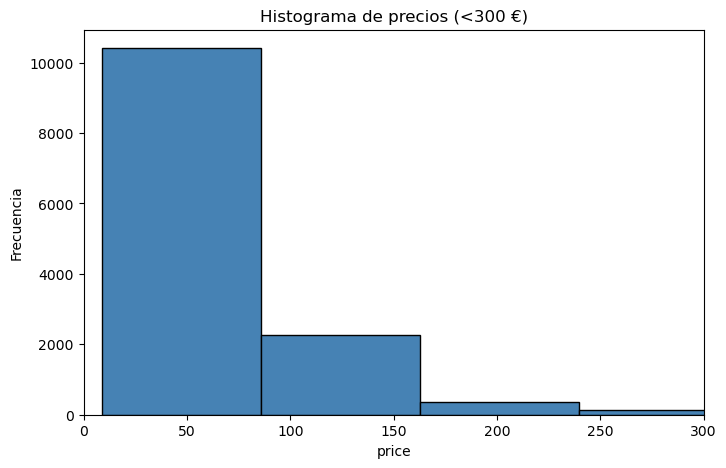

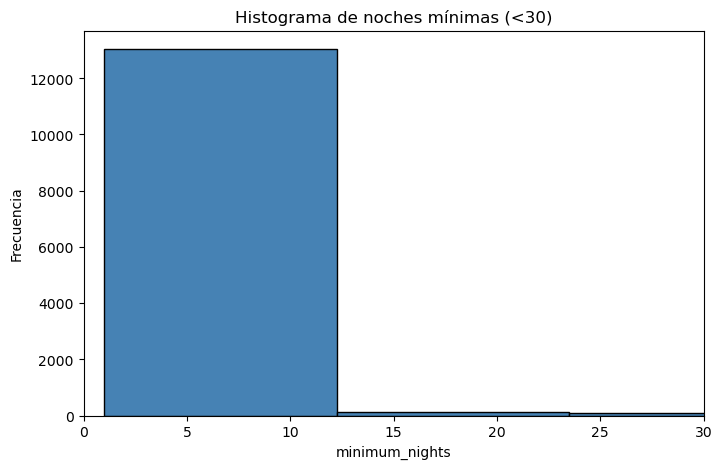

In [10]:
graf_dict={
    "price": "Histograma de precios (<300 €)",
    "minimum_nights":"Histograma de noches mínimas (<30)"
}

def graf(df,
         graf_dict,
         bins=100,
         figsize=(8,5),
         color="steelblue",
         edgecolor="black"):
    """
    Dibuja histogramas para múltiples columnas y limita el eje X si el título contiene un umbral con formato '<N'.

    Parameters
    ----------
    df : DataFrame con las columnas numéricas a graficar.
    graf_dict : Mapeo {nombre_columna: título_de_gráfico}.
    bins : Número de bins del histograma.
    figsize : Tamaño de la figura en pulgadas.
    color : Color de las barras del histograma.
    edgecolor : Color del borde de las barras.

    Returns
    -------
    None

    """
    for col, title in graf_dict.items():

        plt.figure(figsize=figsize)
        plt.hist(df[col], bins=bins, edgecolor=edgecolor, color=color)
        plt.title(title)
        plt.xlabel(col)
        plt.ylabel("Frecuencia")
        # Aquí es donde usamos el threshold, buscamos en el value del docstring el valor tras < y usamos plt.xlim para limitar eje x
        i = title.find('<')
        if i != -1:
            s = title[i+1:]
            j = 0
            while j < len(s) and (s[j].isdigit() or s[j] in '.,'):
                j += 1
            if j:
                plt.xlim(0, float(s[:j].replace(',', '.')))

    plt.show()


graf(df, graf_dict, bins=100)

Para ver detenidamente el tema de los outliers o valores anómalos, hacemos uso de la función `df.describe()`. Aprovechamos para ver más en detalle todo el tema de cuartiles con el objetivo de detectar cambios bruscos en los valores de las columnas numéricas. Se podrá notar que, en las columnas numéricas, no aparecen datos de modas y valores únicos, mientras que para las columnas tipo _object_ no hay valores a nivel cuartílico.

In [11]:
df.describe(include="all")

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,13321,13321,13321.000000,13321.000000,13321,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000,13321.000000
unique,21,126,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,Centro,Embajadores,NaN,NaN,Entire home/apt,NaN,NaN,NaN,NaN,NaN,NaN
freq,6773,1848,NaN,NaN,7926,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,40.420730,-3.697268,NaN,69.171834,3.010885,22.986037,1.520329,7.605885,205.867202
std,NaN,NaN,0.020344,0.023832,NaN,103.721126,12.835619,38.406006,1.852367,19.619972,126.968961
min,NaN,NaN,40.331888,-3.863907,NaN,9.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,NaN,NaN,40.410090,-3.707856,NaN,31.000000,1.000000,1.000000,0.110000,1.000000,84.000000
50%,NaN,NaN,40.418731,-3.701602,NaN,53.000000,2.000000,7.000000,0.780000,2.000000,247.000000
75%,NaN,NaN,40.427997,-3.693818,NaN,80.000000,3.000000,28.000000,2.320000,4.000000,321.000000


Debemos mencionar también los distintos valores únicos de las variables object, pues en este caso destaca la columna de `neighbourhood`, con un total de 126 valores únicos, aunque el número sea elevado, son claras candidatas a ser transformadas a tipo _category_.

Notamos por último que los tipos que hay asignados (_float64_) a las columnas numéricas son excesivamente precisos para este tipo de datos. Merece la pena plantearse hacer "downcast", es decir, reducir los tipos, para ahorrar memoria en disco y agilizar los cálculos.

Intentamos ver en más detalle los percentiles haciendo uso de la función `quantile`.

In [12]:
q = df.select_dtypes(include=np.number).quantile([0, .01,.05,.50,.95,.99, 1]).T
q.columns = ["min", "p01","p05","p50","p95","p99", "max"]
q.sort_values("p99", ascending=False)


,min,p01,p05,p50,p95,p99,max
availability_365,0.000000,0.000000,0.000000,247.000000,364.000000,365.000000,365.000000
price,9.000000,13.000000,18.000000,53.000000,160.000000,354.800000,7700.000000
number_of_reviews,0.000000,0.000000,0.000000,7.000000,101.000000,184.800000,446.000000
calculated_host_listings_count,1.000000,1.000000,1.000000,2.000000,38.000000,145.000000,145.000000
latitude,40.331888,40.370844,40.392201,40.418731,40.461757,40.483360,40.562736
minimum_nights,1.000000,1.000000,1.000000,2.000000,7.000000,25.800000,1125.000000
reviews_per_month,0.000000,0.000000,0.000000,0.780000,5.360000,7.740000,17.210000
longitude,-3.863907,-3.755636,-3.725365,-3.701602,-3.653211,-3.605062,-3.526821


Tal y como se había comentado antes, los valores de precio son anormalmente altos cerca del máximo. De igual forma, las noches mínimas son extremadamente altas en torno al máximo, dado que son alojamientos turísticos no es lo habitual que la mínima estancia sean tantos días. Por ahora, se trabajará en modelos a estos datos en crudo, sin hacer suposiciones para filtrarlos.

Sería interesante probar estos modelos haciendo suposiciones sobre los datos, y ver qué diferencias encontramos.

Para el estudio de las correlaciones recordemos que en la pestaña `Correlations` del EDA automatizado tenemos una visión de cómo se correlacionan las distintas variables, en particular:
- _latitud_ y _longitud_ se relacionan con _neighbourhood_group_, tiene bastante sentido.
- _number_of_reviews_ se relaciona _reviews_per_month_, son causa directa así que tiene bastante sentido.

Debe recordarse que la matriz de correlación usual sólamente permite comparar variables del tipo numérico, y esta libreria nos ha permitido comparar variables categoricas, mixtas etc. Esto es posible ya que no se usa la misma métrica para cada uno de los cálculos de la correlación. Véase la documentación de `ydata_profiling` para más detalles.

## TL;DR

El CSV tiene 13321 filas y 11 columnas, no hay valores nulos ni duplicados. Hay desbalanceos, como el caso de  _room_type_. La variable categórica _neighbourhood_ muestra cardinalidad alta, lo que hace que debamos trabajar con cuidado `OneHotEncoder` (agrupando incluso si fuera necesario). En numéricas (_price, reviews_per_month, availability_365_) se observan colas largas (p95–p99 alejados de p50), por lo que probaremos `RobustScaler` en KNN. La correlación entre numéricas es moderada, así no se aprecia colinealidad problemática para los modelos elegidos.

# Preprocesado de datos
Antes de aplicar los modelos, debemos aplicar un preprocesado a las columnas categóricas y numéricas. Como vimos al ejecutar `df.info()` tenemos varias columnas de tipo `object`, las transformamos en tipo `category` para poder hacer el preprocesado correctamente. Además, veremos que ahorramos en gasto en memoria al hacer esta transformación. Antes de hacer la transformación, vemos explícitamente todos los posibles valores de ambas columnas por si hubiese que hacer alguna transformación previa. En caso contrario, transformamos directamente.

In [13]:
cols = ['neighbourhood_group', 'neighbourhood', 'room_type']

for c in cols:
    print(f"\n-- Valores únicos en {c} --")
    for val in df[c].unique():
        print(val)


-- Valores únicos en neighbourhood_group --
Centro
Moncloa - Aravaca
Latina
Fuencarral - El Pardo
Arganzuela
San Blas - Canillejas
Puente de Vallecas
Chamberí
Usera
Salamanca
Retiro
Tetuán
Ciudad Lineal
Villa de Vallecas
Villaverde
Carabanchel
Chamartín
Hortaleza
Barajas
Moratalaz
Vicálvaro

-- Valores únicos en neighbourhood --
Justicia
Embajadores
Argüelles
Casa de Campo
Cármenes
Universidad
Peñagrande
Legazpi
Sol
Palos de Moguer
Rejas
San Diego
Trafalgar
Almendrales
Acacias
Goya
Palacio
Cortes
Arapiles
Recoletos
Pacífico
Cuatro Caminos
Palomeras Bajas
Valverde
Pueblo Nuevo
Almagro
Pilar
Rios Rosas
Casco Histórico de Vallecas
Los Angeles
Castellana
Buenavista
Pradolongo
Puerta del Angel
Salvador
Hispanoamérica
Puerta Bonita
Canillas
Guindalera
El Viso
San Isidro
Valdefuentes
Berruguete
Gaztambide
Aluche
Vista Alegre
Ciudad Jardín
Almenara
Timón
Niño Jesús
Prosperidad
Estrella
Fuente del Berro
Adelfas
Numancia
Valdeacederas
Ibiza
Bellas Vistas
Imperial
Opañel
Vinateros
Rosas
Jerónimo

Dado esto, podemos confirmar que estas columnas no tienen errores tipográficos, ni es necesario estandarizar antes, así que las transformaremos al tipo correspondiente directamente. Además, haremos un downcast del resto de columnas numéricas para poder ahorrar en memoria.

In [14]:
float_cols = df.select_dtypes(include=['float64']).columns
for col in float_cols:
    df[col] = pd.to_numeric(df[col], downcast='float')

int_cols = df.select_dtypes(include=['int64']).columns
for col in int_cols:
    df[col] = pd.to_numeric(df[col], downcast='integer')

object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    df[col] = df[col].astype('category')

df.info()

df_mem_usage_1=df.memory_usage(deep=True).sum()/1024

mem_usage_improv=(df_mem_usage_0 - df_mem_usage_1)/df_mem_usage_0 *100

print(f"La mejora en memoria ha sido de {round(mem_usage_improv,2)}%, pasando de {df_mem_usage_0:2f} Kb a {df_mem_usage_1:2f} Kb")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13321 entries, 0 to 13320
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   neighbourhood_group             13321 non-null  category
 1   neighbourhood                   13321 non-null  category
 2   latitude                        13321 non-null  float32 
 3   longitude                       13321 non-null  float32 
 4   room_type                       13321 non-null  category
 5   price                           13321 non-null  int16   
 6   minimum_nights                  13321 non-null  int16   
 7   number_of_reviews               13321 non-null  int16   
 8   reviews_per_month               13321 non-null  float32 
 9   calculated_host_listings_count  13321 non-null  int16   
 10  availability_365                13321 non-null  int16   
dtypes: category(3), float32(3), int16(5)
memory usage: 331.2 KB
La mejora en memoria

A nivel de preprocesado universal, a priori solo destacaremos este downcast y el cambio a tipo categórico en las columnas pertinentes. Después de la división en _training set_ y _test set_ haremos un procesado distinto (sobre el set de entreno) para cada uno de los modelos, pues cada uno de ellos requerirá que ciertos requisitos se cumplan. Estos se enumerarán más adelante.

## Set de entreno y set de validación

Para esto, usamos la función `StratifiedShuffleSplit`, indicamos que el parámetro `n_splits=1` porque solo necesitamos un set de pruebas,  `test_size=0.2`  tal y como pide el enunciado. Ponemos la semilla (`random_state=21`) para permitir reproducibilidad

In [15]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=21)

for train_index, test_index in split.split(df, df["room_type"]):
 strat_train_set = df.iloc[train_index]
 strat_test_set = df.iloc[test_index]

#Imprimimos por pantalla las proporciones de cada uno de los sets, para poder comparar.
print(df["room_type"].value_counts()/len(df))
print(strat_test_set["room_type"].value_counts() / len(strat_test_set))
print(strat_train_set["room_type"].value_counts() / len(strat_train_set))

room_type
Entire home/apt    0.595000
Private room       0.390586
Shared room        0.014413
Name: count, dtype: float64
room_type
Entire home/apt    0.595122
Private room       0.390619
Shared room        0.014259
Name: count, dtype: float64
room_type
Entire home/apt    0.594970
Private room       0.390578
Shared room        0.014452
Name: count, dtype: float64


Vemos que las proporciones son muy similares a lo obtenido en el set de datos completo, comprobamos que no hay solape entre los sets de entreno y validación para evitar _data leakage_.

In [16]:
solape = set(strat_train_set.index).intersection(set(strat_test_set.index))
print(solape)

set()


Una vez visto que el split se ha hecho correctamente, dividimos los datos en la clase a predecir y los atributos.

In [17]:
target = "room_type"
X_train = strat_train_set.drop(columns=[target])
y_train = strat_train_set[target]
X_test  = strat_test_set.drop(columns=[target])
y_test  = strat_test_set[target]

Hacemos la división de columnas numéricas y categóricas para la siguiente sección.

In [18]:
num_cols = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['category']).columns.tolist()

Tras haber hecho una primera exploratoria de datos y haber dividido el conjunto de datos en _train set_ y _test set_, procedemos a trabajar los casos particulares de los modelos, pues cada uno de ellos requerirá un tratamiento diferente dado los supuestos bajo los que trabajan.

## Pipelines
En primer lugar escalamos las variables numéricas, para ello probamos en primer lugar a estandarizar.  Usamos `handle_unknown="ignore"` para que categorías nuevas en test no rompan los pipeline.  

### Preprocesado para **Naive Bayes**
Las variables incluyen un bloque importante de categóricas (sin orden) y un conjunto de numéricas. En este escenario, dos variantes de Naive Bayes encajan especialmente bien:

##### 1) CategoricalNB
Supone independencia condicional entre atributos y características categóricas discretas sin orden. Las columnas numéricas se discretizan en intervalos mediante `KBinsDiscretizer`, de forma que el modelo trata todos los predictores como categoría (bins).

##### 2) ComplementNB
Es una variante de Naive Bayes diseñada para ser más robusta en clases desbalanceadas y en espacios de características dispersos (típico tras `OneHotEncoder`). Tras codificar categóricas y asegurar que las características son no negativas (requisito para este modelo), `ComplementNB` se vuelve una línea base muy sólida y eficiente computacionalmente para comparar contra otros modelos.

#### Decisión y comparación
En lugar de GaussianNB (que asume continuidad y normalidad en cada feature, se probó para este dataset pero no se logró una _accuracy_ superior a 0.2), preferimos CategoricalNB y ComplementNB (ambas con discretización) porque se ajustan mejor a la naturaleza del dataset. Entre ellas, se ha escogido **ComplementNB** porque, tras pruebas previas, había conseguido mejor puntuación.

Dentro de `ColumnTransformer` usamos `KBinsDiscretizer` para discretizar las variables numéricas (se han escogido 15 bins arbitrariamente) y `OneHotEncoder` porque ComplementNB trabaja con matrices dispersas (por eso se marca dentro de KBinsDiscretizer `encode="onehot"` y `space_threshold=1`, para que en cualquier caso sea dispersa la matriz)

In [19]:
preprocessor_conb = ColumnTransformer(
    transformers=[
        ("num", KBinsDiscretizer(n_bins=15, encode="onehot", strategy="quantile"), num_cols),
        ("cat",  OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols),
    ],
    sparse_threshold=1.0
)

### Preprocesado para **KNN**

**KNN** decide por distancia.  
Si las variables numéricas están en escalas muy distintas, las de mayor magnitud dominan la distancia y el vecindario deja de ser representativo. Por eso es obligatorio escalar las columnas numéricas (las categóricas ya quedan en \{0,1\} tras `OneHotEncoder` y no requieren escalado).

Escalamos solo el bloque numérico del `ColumnTransformer`. Usamos `RobustScaler` ya que es robusto a outliers, por lo que encaja mejor con el EDA que muestra colas pesadas en algunas numéricas.

In [20]:
preprocessor_knn = ColumnTransformer([
    ("num",RobustScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

### Preprocesado para **Decision Tree**

Un **árbol** toma decisiones comparando umbrales en cada variable. Multiplicar o estandarizar una columna no cambia el orden de sus valores ni las posicionesde corte; por eso no es necesario aplicar `StandardScaler`/`RobustScaler` a las numéricas, aprovechamos el argumento `"passthrough"`.

Para variables categóricas sin orden, aplicamos `OneHotEncoder` para evitar introducir una ordinalidad artificial (que sí sucedería con `OrdinalEncoder`).  


In [21]:
preprocessor_dt = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

### Definición de las pipelines

Una vez definidos los preprocesados, pasamos a definir las pipelines para poder evaluar los modelos.

Para los **Árboles de decisión** el parámetro `class_weight = balanced` para el tratamiento de las clases desbalanceadas, este parámetro permite compensar las clases desiguales dándoles más peso.

Para **KNN** no hay un parametro explícito que trate con clases desbalanceadas, así que usamos los argumentos por defecto.

In [22]:
pipe_conb = Pipeline([
    ("prep", preprocessor_conb),
    ("clf", ComplementNB())
])

pipe_knn = Pipeline([
    ("prep", preprocessor_knn),
    ("clf", KNeighborsClassifier())
])

pipe_dt  = Pipeline([
    ("prep", preprocessor_dt),
    ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=21))
])

### CROSS-VALIDATION

Validación cruzada estratificada (10 splits) para estimar la capacidad de generalización de cada modelo y evitar conclusiones sesgadas por una sola partición. Siguiendo el enunciado, evaluamos la accuracy con `cv=10` y reportamos media ± desviación estándar (y rango) para comparar de forma robusta KNN, Árboles y Naive Bayes. 
Es obligatorio remarcar aquí que se seguirán las pautas del enunciado, pero estas no son las mejores prácticas para el caso en que los datos estén desbalanceados. Es decir, el `scoring` no debería ser _accuracy_ porque un modelo que tiende a predecir correctamente la clase mayoritaria pero no sabre predecir la clase minoritaria tendrá un _accuracy_ alto. Sería conveniente haber usado en su lugar _macro F1 Score_ (la media aritmética de _F1 Score_) o alguna métrica que considere el recall.
Tampoco es adecuado habiendo datos desbalanceados usar `cv=10`. Aquí lo inteligente hubiese sido usar `cv=StratifiedKFold(n_splits=10, shuffle=True, random_seed=21)`, ya que con `cv=10` dependemos del orden de los datos para la estratificación, siendo posible que en alguno de los folds no se encontrase el dato desbalanceado (en este caso `room_type= Shared room`) de manera que el scoring final puede llegar a estar sobreestimado.

In [23]:
scoring="accuracy"
cv=10

def cv_eval_ranking(d:dict, X_train, y_train, scoring, cv):

    """
    Evalúa una colección de modelos (estimadores/pipelines) mediante validación cruzada,
    imprime un ranking (media ± desviación estándar), dibuja un gráfico comparativo y
    devuelve el mejor modelo según la media de CV (desempate por menor desviación estándar).
    Utiliza `X_train`, `y_train`, `scoring` y `cv` definidos en el ámbito actual.

    Parameters
    ----------
    d : dict[str, estimator]
        Diccionario {nombre_legible: pipeline} compatible con scikit-learn.

    Returns
    -------
    best_name : str
        Nombre del modelo con mayor media de validación cruzada (con desempate por menor std).
    best_pipe : estimator
        Estimador/pipeline asociado a `best_name`, listo para ajustarse en el conjunto completo.
    """

    scores = {}
    for name, est in d.items():
        scores[name] = cross_val_score(est, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1)
    
    df_cv = pd.DataFrame(scores)
    
    summary = (
        df_cv.agg(['mean','std']).T
             .sort_values('mean', ascending=True)
    )
    
    best_name = (
        summary.sort_values(['mean', 'std'], ascending=[False, True])
               .index[0]
    )
    
    best_pipe=d[best_name]
    
    print(f"--- Ranking {scoring} (media ± std) ---")
    print((summary['mean'].round(3).astype(str) + " ± " + summary['std'].
           round(3).astype(str)).sort_values(ascending=False))
    
    plt.figure(figsize=(9,5))
    plt.barh(summary.index, summary['mean'], xerr=summary['std'], capsize=4)
    plt.xlabel(f"{scoring.capitalize()} (media CV)")
    plt.title(f"Comparativa de {scoring} – 10-fold CV")
    plt.grid(axis="x", linestyle="--", alpha=0.4)
    plt.xlim(0.5, 1)
    plt.tight_layout()
    plt.show()

    return best_name, best_pipe
        

--- Ranking accuracy (media ± std) ---
DecisionTree inicial    0.857 ± 0.013
KNN inicial              0.824 ± 0.01
ComplementNB inicial    0.822 ± 0.014
dtype: object


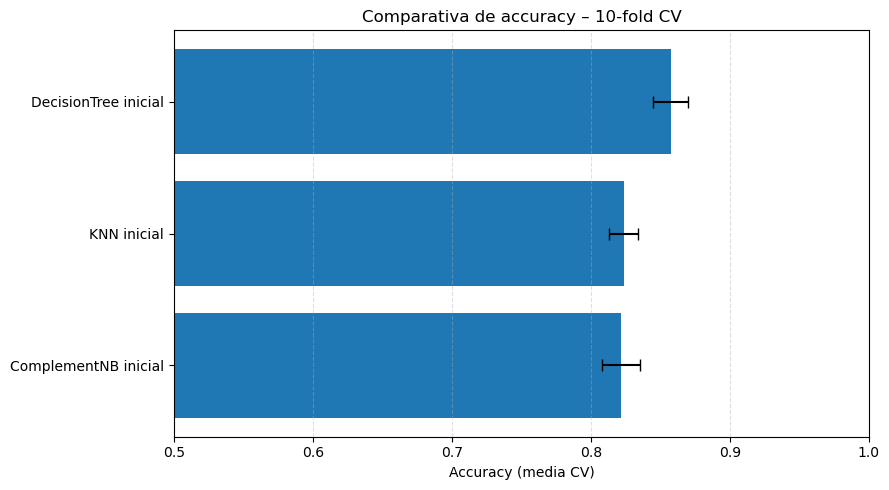

In [24]:
modelos = {
    "ComplementNB inicial": pipe_conb,
    "KNN inicial": pipe_knn,
    "DecisionTree inicial": pipe_dt
}

best_name, best_pipe = cv_eval_ranking(modelos, X_train, y_train, scoring, cv)

## Métricas y decisiones

Dado que claramente el árbol de decisión ha sido el modelo que mejor ha puntuado, debemos entrenar el modelo para ver cómo puntuará al aplicarle el _test set_.

In [25]:
def confusion_matrix_best_model(best_pipe, best_name, X_train, y_train, X_test, y_test,normalize=None, dt_details=None):
    """
    Ajusta el pipeline seleccionado sobre los datos de entrenamiento, imprime el
    reporte de clasificación en test y muestra la matriz de confusión (absoluta o
    normalizada). Opcionalmente, si el clasificador final expone `get_depth` y
    `get_n_leaves` (DecisionTree), informa su profundidad y número de hojas.

    Parameters
    ----------
    best_pipe : Pipeline o estimador compatible con scikit-learn
        Modelo ganador que se ajustará con `X_train`, `y_train` y se evaluará en test.
    best_name : str
        Alias legible del modelo, usado en los títulos/impresiones.
    X_train : array-like
        Datos de entrenamiento.
    y_train : array-like
        Etiquetas de entrenamiento.
    X_test : array-like
        Datos de prueba/validación final.
    y_test : array-like
        Etiquetas de prueba/validación final.
    normalize : {'true', 'pred', 'all', None}, default=None
        Esquema de normalización de la matriz de confusión:
        - None  : cuentas absolutas.
        - 'true': normaliza por filas (aprox. recall por clase).
        - 'pred': normaliza por columnas (aprox. precision por clase).
        - 'all' : normaliza por el total.
    dt_details : bool
        Si es True, intenta imprimir `get_depth()` y `get_n_leaves()` del step `'clf'`
        del pipeline (si existe y está soportado).

    Returns
    -------
    None
    """
    
    best_pipe.fit(X_train, y_train)
    if dt_details:
        clf = best_pipe.named_steps["clf"]
        print(f"Profundidad: {clf.get_depth()} | Hojas: {clf.get_n_leaves()}")
    y_pred = best_pipe.predict(X_test)
    print("\n--- Reporte de Clasificación (test) ---")
    print(classification_report(y_test, y_pred, digits=3))
    
    ConfusionMatrixDisplay.from_estimator(
        best_pipe, X_test, y_test,
        cmap="Blues", normalize=normalize
    )
    plt.title(f"Matriz de confusión – {best_name} (test)")
    plt.tight_layout()
    plt.show()

Profundidad: 28 | Hojas: 1227

--- Reporte de Clasificación (test) ---
                 precision    recall  f1-score   support

Entire home/apt      0.895     0.895     0.895      1586
   Private room      0.822     0.825     0.824      1041
    Shared room      0.400     0.368     0.384        38

       accuracy                          0.860      2665
      macro avg      0.706     0.696     0.701      2665
   weighted avg      0.860     0.860     0.860      2665



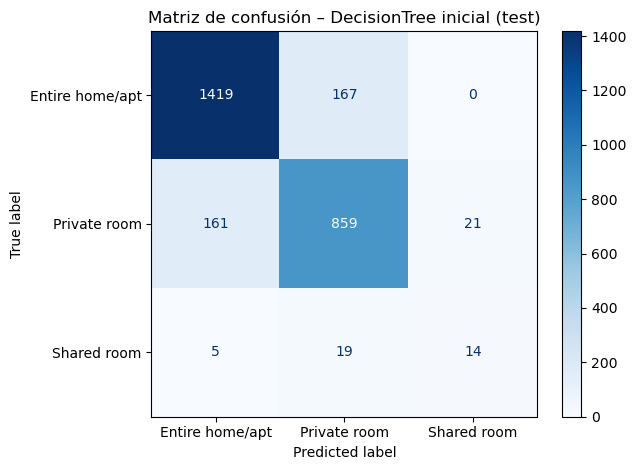

In [26]:
confusion_matrix_best_model(best_pipe=best_pipe,
                            best_name=best_name,
                            X_train=X_train,
                            y_train=y_train,
                            X_test=X_test, 
                            y_test=y_test,
                            dt_details=True)

El árbol de decisión que se ha escogido tiene una profundidad máxima de 28 y 1227 hojas, dada la rejilla del enunciado a la que aplicar el `GridSearchCV`, con total seguridad conseguiremos una peor puntuación ya que la rejilla no encapsula los parámetros óptimos.

# Ajuste de hiperparámetros con GridSearch

Tras comprobar que el modelo inicial más prometedor es el Árbol de Decisión, intentamos ajustar los hiperparámetros de KNN y el árbol de decisión mediante `GridSearchCV`. El objetivo es ver si alguna combinación de parámetros mejora la accuracy obtenida anteriormente. Como primer paso, definimos la rejilla de hiperparámetros que exploraremos para cada algoritmo.
A destacar que respecto a árboles de decisión, en el enunciado se solicitaba 
> Para Árboles de decisión: variando max_leaf_nodes entre 2 y 50 ambos 
inclusive, min_samples_split entre 2 y 6 ambos inclusive y max_depth entre 1 y 
20 ambos inclusive.

Si usamos el grid 
```python
param_grid_dt ={
        'clf__max_leaf_nodes': list(range(2, 51)),
        'clf__min_samples_split': list(range(2, 7)),
        'clf__max_depth': list(range(1, 21)),
    }
```
las combinaciones totales de esta búsqueda son 49*5*20= 4900 combinaciones, teniendo en cuenta que `cv=10`, son un total de 49000 evaluaciones.
Debe comentarse que lo más óptimo aquí es usar `RandomizedSearchCV` en lugar de `GridSearchCV` para obtener una solución muy aproximada a la real, sin embargo siguiendo el enunciado usaremos `GridSearchCV`. Sería de esperar que aprovechasemos la relación entre el máximo de hojas y el máximo de profundidad, ya que dado $L$ el máximo de hojas y $d$ el máximo de profundidad, en un arbol equilibrado y completo se verifica:
$$L=2^d$$
Sin embargo, el arbol no tiene por qué ser equilibrado, así que simplemente dejamos el grid tal y como lo marca el enunciado.

In [27]:
param_grid_dt = {
        'clf__max_leaf_nodes': list(range(2, 51)),
        'clf__min_samples_split': list(range(2, 7)),
        'clf__max_depth': list(range(1,21)),
    }

param_grid_knn = {
    "clf__n_neighbors": list(range(2, 30))
}

Antes de ejecutar la búsqueda, implementamos una función genérica que realiza el GridSearchCV dado un pipeline y una rejilla de parámetros. Esta función entrenará múltiples configuraciones en validación cruzada y, al finalizar, mostrará la mejor combinación encontrada junto a la matriz de confusión y el informe de clasificación (precision, recall, f1) del modelo óptimo resultante. Esto nos agiliza repetir el proceso para cada clasificador.

In [28]:
def run_grid_search(
    name: str,
    pipeline,
    param_grid: dict | list,
    X_train, y_train,
    X_test,  y_test,
    scoring: str = "accuracy",
    cv: int = 10,
    n_jobs: int = -1,
    verbose: int = 1,
):
    """
    Ejecuta un GridSearchCV sobre un pipeline, reporta métricas clave y devuelve el mejor modelo.

    Parameters
    ----------
    name : str
        Alias legible del modelo (se usa solo para impresión en consola).
    pipeline : pipeline
        Pipeline o estimador compatible con scikit-learn que se ajustará.
    param_grid : dict | list 
        Espacio de búsqueda de hiperparámetros para `GridSearchCV`. Puede ser un diccionario
        o una lista de diccionarios (búsquedas por etapas).
    X_train : array-like
        Datos de entrenamiento.
    y_train : array-like
        Etiquetas de entrenamiento.
    X_test : array-like
        Datos de prueba/validación final para evaluar el mejor estimador.
    y_test : array-like
        Etiquetas de prueba/validación final.
    scoring : str
        Métrica de evaluación para `GridSearchCV`. Cualquier string/callable válido en scikit-learn.
    cv : int
        Número de particiones o un generador de validación cruzada compatible.
    n_jobs : int
        Número de trabajos en paralelo para el grid search (-1 usa todos los cores disponibles).
    verbose : Nivel de verbosidad de `GridSearchCV`.

    Returns
    -------
    best_model : Mejor estimador encontrado (`gs.best_estimator_`) ya ajustado sobre todo `X_train`.
    gs : Objeto `GridSearchCV` completo, con resultados de la búsqueda (`cv_results_`, `best_params_`, etc.).
        """

    print(f"\n--- {name} ---")

    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=verbose
    )

    gs.fit(X_train, y_train)

    print(f"Mejores parámetros: {gs.best_params_}")
    print(f"Mejor {scoring} en CV: {gs.best_score_:.4f}")

    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test)

    print("--- Reporte de Clasificación ---")
    print(classification_report(y_test, y_pred, digits=3))
    print(confusion_matrix(y_test, y_pred))

    return best_model, gs

Probamos primero la función de búsqueda de hiperparámetros con el modelo de mejor desempeño hasta ahora, el Árbol de Decisión, para ver si podemos afinar aún más su precisión.

In [29]:
best_dt,  gs_dt  = run_grid_search(
    name="Decision Tree",
    pipeline=pipe_dt,
    param_grid=param_grid_dt,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    scoring=scoring,
    cv=cv
)


--- Decision Tree ---
Fitting 10 folds for each of 4900 candidates, totalling 49000 fits
Mejores parámetros: {'clf__max_depth': 8, 'clf__max_leaf_nodes': 50, 'clf__min_samples_split': 2}
Mejor accuracy en CV: 0.8154
--- Reporte de Clasificación ---
                 precision    recall  f1-score   support

Entire home/apt      0.919     0.881     0.900      1586
   Private room      0.830     0.710     0.765      1041
    Shared room      0.094     0.632     0.164        38

       accuracy                          0.811      2665
      macro avg      0.615     0.741     0.610      2665
   weighted avg      0.873     0.811     0.837      2665

[[1398  142   46]
 [ 118  739  184]
 [   5    9   24]]


Probamos ahora a hacer la afinación de hiperparámetros para KNN.

In [30]:
best_knn, gs_knn= run_grid_search(
name= "K-Nearest Neighbourhood",
    pipeline=pipe_knn,
    param_grid=param_grid_knn,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    scoring=scoring,
    cv=cv
)


--- K-Nearest Neighbourhood ---
Fitting 10 folds for each of 28 candidates, totalling 280 fits
Mejores parámetros: {'clf__n_neighbors': 7}
Mejor accuracy en CV: 0.8246
--- Reporte de Clasificación ---
                 precision    recall  f1-score   support

Entire home/apt      0.855     0.868     0.862      1586
   Private room      0.783     0.787     0.785      1041
    Shared room      0.889     0.211     0.340        38

       accuracy                          0.827      2665
      macro avg      0.842     0.622     0.662      2665
   weighted avg      0.828     0.827     0.824      2665

[[1377  209    0]
 [ 221  819    1]
 [  12   18    8]]


Tras el `GridSearchCV` (ya tenemos cada `best_estimator_`), comparamos todos los modelos bajo el mismo CV y misma métrica para una evaluación justa.

La celda crea un diccionario con defecto vs óptimo, ejecuta `cross_val_score`, muestra ranking (media ± std) y un gráfico de barras con error.

Cuanta mayor es la media, mejor será el modelo, a igualdad de medias escogemos el que menor std tenga.

--- Ranking accuracy (media ± std) ---
Árbol inicial           0.857 ± 0.013
KNN GridSearch          0.825 ± 0.014
KNN inicial              0.824 ± 0.01
ComplementNB inicial    0.822 ± 0.014
Árbol GridSearch        0.815 ± 0.016
dtype: object


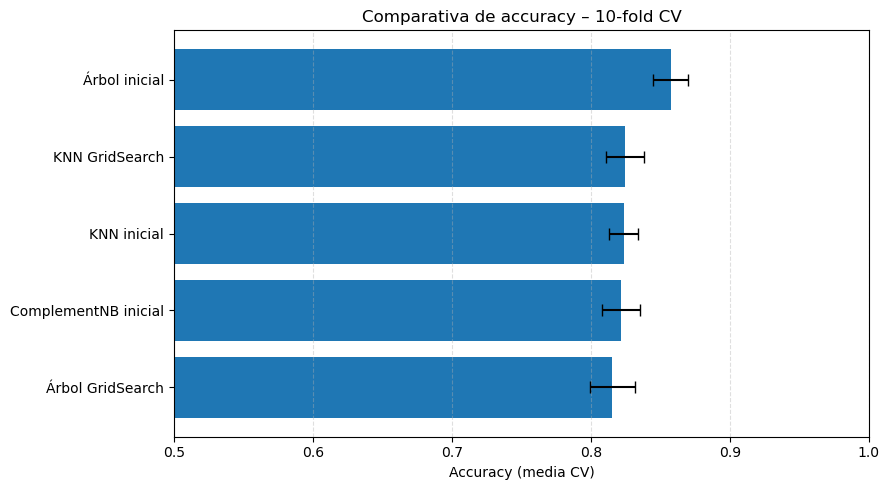

In [31]:
modelos_gs = {
    "ComplementNB inicial": pipe_conb,
    "KNN inicial": pipe_knn,
    "Árbol inicial": pipe_dt,
    "KNN GridSearch": gs_knn.best_estimator_,
    "Árbol GridSearch": gs_dt.best_estimator_
}

best_name,best_ranking=cv_eval_ranking(modelos_gs, X_train, y_train, scoring, cv)

Graficamos la matriz de confusión del mejor modelo y mostramos de nuevo las métricas:


--- Reporte de Clasificación (test) ---
                 precision    recall  f1-score   support

Entire home/apt      0.895     0.895     0.895      1586
   Private room      0.822     0.825     0.824      1041
    Shared room      0.400     0.368     0.384        38

       accuracy                          0.860      2665
      macro avg      0.706     0.696     0.701      2665
   weighted avg      0.860     0.860     0.860      2665



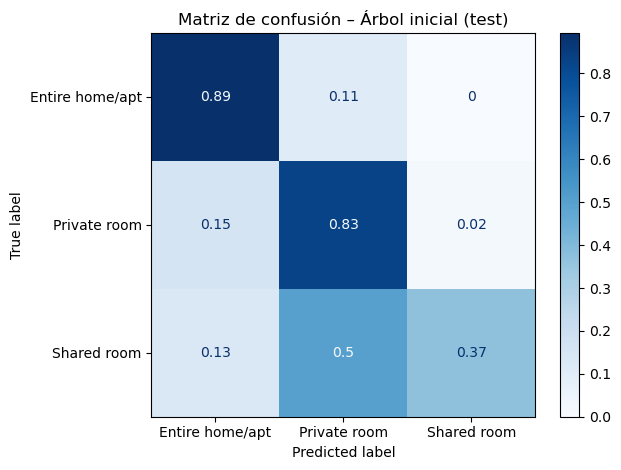

In [32]:
confusion_matrix_best_model(best_pipe=best_pipe,
                            best_name=best_name,
                            X_train=X_train,
                            y_train=y_train,
                            X_test=X_test, 
                            y_test=y_test,
                            normalize="true")

## ¿Y si aplicasemos buenas prácticas?

Se ha comentado anteriormente que podíamos hacer muchas suposiciones sobre este trabajo, ¿que pasaría si aplicasemos algunas de estas hipótesis?
- Quitamos outliers en algunas de las columnas y eliminamos columnas con información redundante.
- `StratifiedKFold` con `shuffle=True`.
- Medimos en base a `F1-macro`, ya que como hay desbalanceo, esta es una medida que nos será útil.
- Grid aumentado con más variables tenidas en cuenta, en busca de una mejora en el modelo
- `RandomizedSearchCV` en lugar de `GridSearchCV` para buscar, aunque no la mejor solución, una buena aproximación
Una vez entrenado el modelo sobre el dataset filtrado, lo probaremos sobre el conjunto de entrenamiento *total*.

Fitting 10 folds for each of 70 candidates, totalling 700 fits
Fitting 10 folds for each of 70 candidates, totalling 700 fits
Mejores KNN: {'prep__num': RobustScaler(), 'prep__cat__min_frequency': 3, 'prep__cat__handle_unknown': 'infrequent_if_exist', 'clf__weights': 'distance', 'clf__p': 2, 'clf__n_neighbors': 7, 'clf__metric': 'minkowski'} → CV: 0.6848879207709044
Mejores Árbol: {'prep__num': 'passthrough', 'prep__cat__min_frequency': 7, 'prep__cat__handle_unknown': 'infrequent_if_exist', 'clf__splitter': 'best', 'clf__min_samples_split': 7, 'clf__max_leaf_nodes': 89, 'clf__max_depth': 8, 'clf__criterion': 'entropy', 'clf__class_weight': None} → CV: 0.7050702312664042
                 precision    recall  f1-score   support

Entire home/apt     0.9008    0.9361    0.9181      1503
   Private room     0.8809    0.8503    0.8654      1009
    Shared room     0.8571    0.3158    0.4615        38

       accuracy                         0.8929      2550
      macro avg     0.8796    0.70

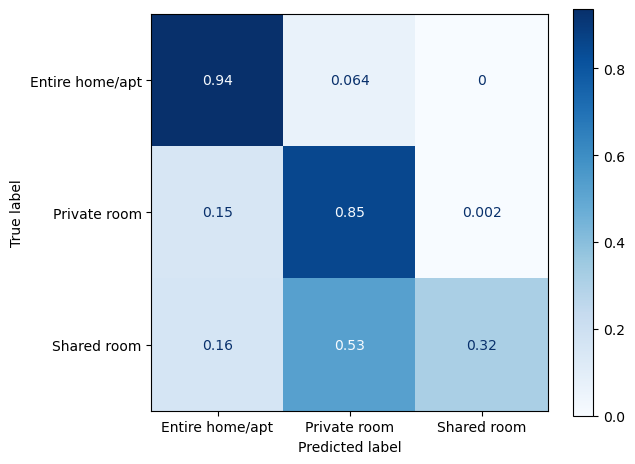

In [33]:
scoring_f="f1_macro"
cv_f=StratifiedKFold(n_splits=10, shuffle=True, random_state=21)
target="room_type"

# Creamos un filtro en base a las suposiciones que hacemos
mask = ((df["price"] < 300) & (df["minimum_nights"] < 30)) & (df["number_of_reviews"]<150)

# Creamos una copia del train set filtrando, la idea es entrenar al modelo sin putliers para asegurar un entreno más robusto
strat_train_set_f=strat_train_set.loc[mask].copy()
strat_test_set_f=strat_test_set.loc[mask].copy()

#Borramos además columnas redundantes, procuramos dejar neighbourhood_group
columns_to_delete=[ "longitude", "latitude", "neighbourhood", "reviews_per_month"]

X_train_f = strat_train_set_f.drop(columns=[target]+columns_to_delete)
y_train_f = strat_train_set_f[target]
X_test_f=strat_test_set_f.drop(columns=[target]+columns_to_delete)
y_test_f=strat_test_set_f[target]

num_cols_f = X_train_f.select_dtypes(include=['number']).columns.tolist()
cat_cols_f = X_train_f.select_dtypes(include=['category']).columns.tolist()

preprocessor_dt_f = ColumnTransformer([
    ("num", "passthrough", num_cols_f),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_f)
])
preprocessor_knn_f = ColumnTransformer([
    ("num",RobustScaler(), num_cols_f),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_f)
])

pipe_knn_f = Pipeline([
    ("prep", preprocessor_knn_f),
    ("clf", KNeighborsClassifier())
])

pipe_dt_f  = Pipeline([
    ("prep", preprocessor_dt_f),
    ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=21))
])

#Definimos unos grid nuevos para cada modelo, abarcando muchas más opciones
#Escalador, num de vecindarios, pesos, metrica, p, forma de gestionar desconocidos en onehotencoder(ignorar o agrupar) y minimo de frecuencia para agrupar
param_dist_knn = {
    "prep__num": [MinMaxScaler(), StandardScaler(), RobustScaler()],
    "clf__n_neighbors": list(range(3, 101)),         
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],                             
    "clf__metric": ["minkowski"],
    "prep__cat__handle_unknown": ["ignore", "infrequent_if_exist"],
    "prep__cat__min_frequency":list(range(1,15))
}

param_dist_dt = {
    "prep__num": ["passthrough"],
    'clf__max_leaf_nodes': list(range(2, 101)),
    'clf__min_samples_split': list(range(2, 20)),
    'clf__max_depth': list(range(1,51)),
    'clf__criterion': ['gini', 'entropy', 'log_loss'],
    'clf__splitter': ['best', 'random'],
    'clf__class_weight': [None, 'balanced'],
    "prep__cat__handle_unknown": ["ignore", "infrequent_if_exist"],
    "prep__cat__min_frequency":list(range(1,15))
}

#Obtenemos los modelos con RandomizedSearchCV y los entrenamos
rs_knn = RandomizedSearchCV(
    estimator=pipe_knn_f,            
    param_distributions=param_dist_knn,
    n_iter=70,                     
    scoring=scoring_f,
    cv=cv_f,
    random_state=21,
    n_jobs=-1,
    refit=True,
    verbose=1
)
rs_knn.fit(X_train_f, y_train_f)

rs_dt = RandomizedSearchCV(
    estimator=pipe_dt_f,            
    param_distributions=param_dist_dt,
    n_iter=70,
    scoring=scoring_f,
    cv=cv_f,
    random_state=21,
    n_jobs=-1,
    refit=True,
    verbose=1
)
rs_dt.fit(X_train_f, y_train_f)

print("Mejores KNN:", rs_knn.best_params_, "→ CV:", rs_knn.best_score_)
print("Mejores Árbol:", rs_dt.best_params_, "→ CV:", rs_dt.best_score_)

#Escogemos el mejor modelo y lo evaluamos
best_pipe_rs=rs_dt.best_estimator_ if rs_dt.best_score_ > rs_knn.best_score_ else rs_knn.best_estimator_
y_pred_rs = best_pipe_rs.predict(X_test_f)

print(classification_report(y_test_f, y_pred_rs, digits=4))

ConfusionMatrixDisplay.from_estimator(
        best_pipe_rs, X_test_f, y_test_f,
        cmap="Blues", normalize='true'
    )
plt.tight_layout()
plt.show()

Hemos conseguido un mejor modelo en un periodo de tiempo mucho menor, esto ha sido principalmente gracias al `RandomizedSearchCV`.
Hemos seleccionado la métrica _F1-macro_ por ser robusta ante el balanceo. Tras haber entrenado un modelo nuevo sobre un conjunto de datos sin outliers, debemos ver ahora cómo se comporta sobre el conjunto de test original, realizamos lo que suele llamarse _stress_test_:

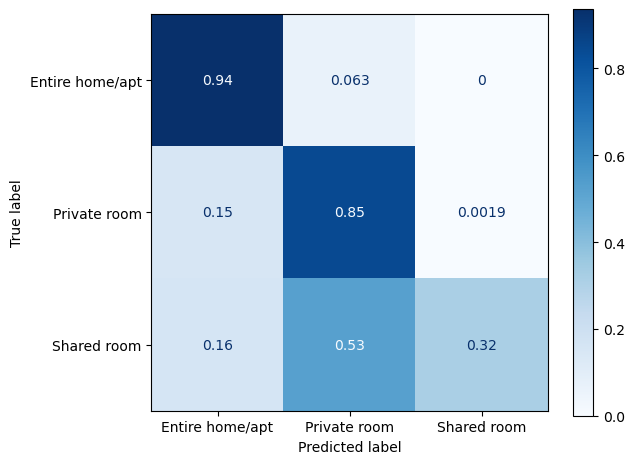

In [34]:
ConfusionMatrixDisplay.from_estimator(
        best_pipe_rs, X_test, y_test,
        cmap="Blues", normalize='true'
    )
plt.tight_layout()
plt.show()

Vemos cómo la matriz de confusión es prácticamente igual, el modelo generaliza bastante bien aun teniendo en cuenta datos anómalos.  

Con el método inicial conseguíamos un arbol con 0.860 accuracy y 0.701 de F1-macro, y con este nuevo árbol conseguimos 0.8929 accuracy y 0.7483 f1-macro, conseguimos una clara mejora.

## Conclusiones
Hemos cumplido con los requisitos del ejercicio: utilizamos un tipado de datos adecuado, optimizamos la memoria (~90% de reducción) al manejar las columnas categóricas, y realizamos una comparativa entre los modelos Naive Bayes, KNN y Árbol de Decisión. Para ello, hemos aprovechado algunos argumentos que nos proporcionan estos modelos

El Árbol de Decisión mostró el mejor rendimiento global, manejando mejor el desbalance de clases y confirmando su alta precisión en el conjunto de test.

La clase minoritaria (Shared room) fue la más difícil de predecir correctamente. Esto sugiere que, con datos más balanceados o usando técnicas que tengan en cuenta esta casuística, podríamos conseguir modelos que predigan más correctamente este tipo de casos.

Debemos añadir que para este problema era esperable que el mejor modelo fuese el árbol de decisión porque capta mejor las relaciones e interacciones entre los datos que KNN o ComplementNB. Un árbol puede crear reglas de que, bajo cierto umbral de precio, un alojamiento en el Centro sea compartido. Sin embargo KNN, que mide por distancias, al introducir OneHotEncode va a hacer que, por ejemplo, pisos iguales salvo barrios distintos quedarán lejos en el espacio de características.A ComplementNB le cuesta capturar interacciones como precio × barrio, por lo que suele quedar por detrás del Árbol en este dataset mixto.

El Árbol de Decisión es el modelo más adecuado en este problema mixto: captura interacciones no lineales entre precio, estancia mínima y contexto urbano (neighbourhood_group), ofreciendo el mejor compromiso de F1-macro con coste computacional contenido gracias a RandomizedSearchCV. La clase Shared room sigue siendo el cuello de botella; con regularización fina, una política de datos coherente.

# Referencias
[1] Actividad 1.pdf del curso virtual  
[2] Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3.ª ed.). O'Reilly Media.  
[3] Lee, W. (2019). Python Machine Learning. John Wiley & Sons.  
[4] VanderPlas, J. (2017). Python Data Science Handbook: Essential Tools for Working with Data. O'Reilly Media.  
[5] Scikit-learn Developers. (n.d.). ComplementNB. En scikit-learn 1.7.2 documentation. https://scikit-learn.org/1.7/modules/generated/sklearn.naive_bayes.ComplementNB.html  
[6] Scikit-learn Developers. (n.d.). CategoricalNB. En scikit-learn 1.7.2 documentation. https://scikit-learn.org/1.7/modules/generated/sklearn.naive_bayes.CategoricalNB.html  
[7] YData. (n.d.). Overview. En YData Profiling. https://docs.profiling.ydata.ai/latest/getting-started/concepts/  
[8] Scikit-learn Developers. (n.d.). StratifiedShuffleSplit. En scikit-learn 1.7.2 documentation. https://scikit-learn.org/1.7/modules/generated/sklearn.model_selection.StratifiedShuffleSplit.html  
[9] Scikit-learn Developers. (n.d.). KNeighborsClassifier. En scikit-learn 1.7.2 documentation. https://scikit-learn.org/1.7/modules/generated/sklearn.neighbors.KNeighborsClassifier.html  
[10] Scikit-learn Developers. (n.d.). KBinsDiscretizer. En scikit-learn 1.7.2 documentation. https://scikit-learn.org/1.7/modules/generated/sklearn.preprocessing.KBinsDiscretizer.html  
[11] Scikit-learn Developers. (n.d.). GridSearchCV. En scikit-learn 1.7.2 documentation. https://scikit-learn.org/1.7/modules/generated/sklearn.model_selection.GridSearchCV.html  
[12} Scikit-learn Developers. (n.d.). cross_val_score. En scikit-learn 1.7.2 documentation. https://scikit-learn.org/1.7/modules/generated/sklearn.model_selection.cross_val_score.html  